<a href="https://colab.research.google.com/github/tripti2746mba25fin-blip/ai-finance-expense-automation-system/blob/main/Lab_3_4_SHAP_LIME_Finance_Explainable_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# LAB 3–4: Explainable AI in Finance using SHAP and LIME
# Topic: Algorithmic Transparency and Explainability in AI-based Loan Approval
# Audience: MBA Finance students
#
# Purpose of this lab:
# 1. Build a synthetic finance dataset for loan approval prediction.
# 2. Train a machine learning model to predict whether a loan should be approved.
# 3. Use SHAP to explain how each feature influences the model globally and locally.
# 4. Use LIME to explain one individual loan decision in simple business language.
#
# Important teaching idea:
# In finance, model accuracy alone is not enough.
# A bank or fintech must also explain why a customer was approved or rejected.
#
# This lab is designed for Google Colab.
# Run each cell one by one from top to bottom.

In [ ]:
# STEP 1: Install required libraries
# Google Colab already has many libraries installed, but SHAP and LIME may need installation.
# The -q flag keeps the installation output short and clean.
#
# SHAP = SHapley Additive exPlanations
# LIME = Local Interpretable Model-agnostic Explanations
#
# SHAP helps us understand feature impact using game theory.
# LIME helps us explain one specific prediction by creating a simple local explanation.

!pip install -q shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# STEP 2: Import required libraries
# pandas: used for working with tabular data
# numpy: used for numerical operations
# matplotlib: used for visualization
# sklearn: used for machine learning model building
# shap: used for global and local explainability
# lime: used for local explainability of individual predictions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import shap
from lime.lime_tabular import LimeTabularExplainer

# This setting helps pandas display more columns clearly.
pd.set_option("display.max_columns", 100)

# This ensures reproducibility.
# Every time students run the notebook, they should get the same synthetic dataset.
np.random.seed(42)

In [ ]:
# STEP 3: Create a synthetic finance dataset
# We are creating a realistic but synthetic loan approval dataset.
# No real customer data is used, so there is no privacy risk.
#
# Each row represents one loan applicant.
# Features are commonly used in lending and credit risk analysis.
#
# Features included:
# - age: applicant age
# - annual_income: yearly income in INR
# - credit_score: creditworthiness indicator
# - existing_emi: current monthly EMI obligations
# - loan_amount: requested loan amount
# - employment_type: salaried, self-employed, or gig worker
# - region: metro, urban, semi-urban, or rural
# - gender: male or female
# - credit_history_years: number of years of formal credit history
# - debt_to_income_ratio: EMI burden compared to monthly income
#
# Target variable:
# - loan_approved: 1 means approved, 0 means rejected

n = 1500

age = np.random.randint(21, 61, n)

annual_income = np.random.normal(850000, 280000, n)
annual_income = np.clip(annual_income, 250000, 2500000)

credit_score = np.random.normal(700, 80, n)
credit_score = np.clip(credit_score, 300, 900)

loan_amount = np.random.normal(600000, 250000, n)
loan_amount = np.clip(loan_amount, 100000, 2000000)

existing_emi = np.random.normal(18000, 9000, n)
existing_emi = np.clip(existing_emi, 0, 80000)

credit_history_years = np.random.randint(0, 20, n)

employment_type = np.random.choice(
    ["Salaried", "Self-Employed", "Gig Worker"],
    size=n,
    p=[0.58, 0.30, 0.12]
)

region = np.random.choice(
    ["Metro", "Urban", "Semi-Urban", "Rural"],
    size=n,
    p=[0.35, 0.30, 0.22, 0.13]
)

gender = np.random.choice(
    ["Male", "Female"],
    size=n,
    p=[0.55, 0.45]
)

monthly_income = annual_income / 12
debt_to_income_ratio = existing_emi / monthly_income

df = pd.DataFrame({
    "age": age,
    "annual_income": annual_income.round(0),
    "credit_score": credit_score.round(0),
    "existing_emi": existing_emi.round(0),
    "loan_amount": loan_amount.round(0),
    "employment_type": employment_type,
    "region": region,
    "gender": gender,
    "credit_history_years": credit_history_years,
    "debt_to_income_ratio": debt_to_income_ratio.round(2)
})

df.head()

,age,annual_income,credit_score,existing_emi,loan_amount,employment_type,region,gender,credit_history_years,debt_to_income_ratio
0,59,694544.0,745.0,11826.0,767883.0,Salaried,Urban,Male,18,0.20
1,49,1376724.0,618.0,12445.0,982008.0,Self-Employed,Semi-Urban,Male,11,0.11
2,35,444556.0,698.0,18964.0,821876.0,Salaried,Urban,Male,7,0.51
3,28,250000.0,686.0,14894.0,790212.0,Self-Employed,Urban,Female,5,0.71
4,41,973204.0,718.0,24191.0,615021.0,Gig Worker,Metro,Female,11,0.30


In [ ]:
# STEP 4: Create the loan approval target using business logic
# Here we simulate how a lending institution might approve or reject loans.
#
# Important:
# This formula is intentionally designed to include realistic lending factors:
# - Higher income increases approval chance.
# - Higher credit score increases approval chance.
# - Higher debt-to-income ratio reduces approval chance.
# - Higher loan amount reduces approval chance.
# - Longer credit history increases approval chance.
#
# We also add small penalties for certain groups to demonstrate how bias can enter.
# For example:
# - Rural region receives a small penalty.
# - Gig workers receive a small penalty.
#
# This is not a recommendation to use these variables unfairly.
# It is included to teach how bias can appear in AI-based financial decision-making.

score = (
    0.004 * (df["credit_score"] - 650)
    + 0.000002 * (df["annual_income"] - 700000)
    - 1.8 * df["debt_to_income_ratio"]
    - 0.000001 * (df["loan_amount"] - 500000)
    + 0.04 * df["credit_history_years"]
)

# Add bias-like penalties for demonstration.
score += np.where(df["region"] == "Rural", -0.35, 0)
score += np.where(df["employment_type"] == "Gig Worker", -0.25, 0)

# Add random variation because real financial decisions are not perfectly deterministic.
score += np.random.normal(0, 0.45, n)

# Convert score into probability using sigmoid function.
approval_probability = 1 / (1 + np.exp(-score))

# Approve loan if probability is above 0.50.
df["loan_approved"] = (approval_probability > 0.50).astype(int)

# Display first few rows with target variable.
df.head()

,age,annual_income,credit_score,existing_emi,loan_amount,employment_type,region,gender,credit_history_years,debt_to_income_ratio,loan_approved
0,59,694544.0,745.0,11826.0,767883.0,Salaried,Urban,Male,18,0.20,1
1,49,1376724.0,618.0,12445.0,982008.0,Self-Employed,Semi-Urban,Male,11,0.11,1
2,35,444556.0,698.0,18964.0,821876.0,Salaried,Urban,Male,7,0.51,0
3,28,250000.0,686.0,14894.0,790212.0,Self-Employed,Urban,Female,5,0.71,0
4,41,973204.0,718.0,24191.0,615021.0,Gig Worker,Metro,Female,11,0.30,1


In [ ]:
# STEP 5: Basic dataset understanding
# Before building any model, finance teams must understand the dataset.
#
# This step helps students observe:
# - Number of rows and columns
# - Data types
# - Missing values
# - Distribution of approved vs rejected applications
#
# In real finance projects, this stage is important for data governance.

print("Dataset shape:", df.shape)
print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nLoan approval distribution:")
print(df["loan_approved"].value_counts(normalize=True).rename("proportion"))

df.head()

Dataset shape: (1500, 11)

Column data types:
age                       int64
annual_income           float64
credit_score            float64
existing_emi            float64
loan_amount             float64
employment_type          object
region                   object
gender                   object
credit_history_years      int64
debt_to_income_ratio    float64
loan_approved             int64
dtype: object

Missing values:
age                     0
annual_income           0
credit_score            0
existing_emi            0
loan_amount             0
employment_type         0
region                  0
gender                  0
credit_history_years    0
debt_to_income_ratio    0
loan_approved           0
dtype: int64

Loan approval distribution:
loan_approved
1    0.612
0    0.388
Name: proportion, dtype: float64


,age,annual_income,credit_score,existing_emi,loan_amount,employment_type,region,gender,credit_history_years,debt_to_income_ratio,loan_approved
0,59,694544.0,745.0,11826.0,767883.0,Salaried,Urban,Male,18,0.20,1
1,49,1376724.0,618.0,12445.0,982008.0,Self-Employed,Semi-Urban,Male,11,0.11,1
2,35,444556.0,698.0,18964.0,821876.0,Salaried,Urban,Male,7,0.51,0
3,28,250000.0,686.0,14894.0,790212.0,Self-Employed,Urban,Female,5,0.71,0
4,41,973204.0,718.0,24191.0,615021.0,Gig Worker,Metro,Female,11,0.30,1


In [ ]:
# STEP 6: Group-wise approval rate analysis
# This is an important ethics and fairness step.
#
# We compare loan approval rates across gender, region, and employment type.
# If one group has a much lower approval rate, we should investigate.
#
# This does not automatically prove discrimination.
# But it is a signal for deeper analysis.

def approval_rate_by_group(column_name):
    return (
        df.groupby(column_name)["loan_approved"]
        .mean()
        .sort_values(ascending=False)
        .round(3)
        .rename("approval_rate")
    )

print("Approval rate by gender:")
print(approval_rate_by_group("gender"))

print("\nApproval rate by region:")
print(approval_rate_by_group("region"))

print("\nApproval rate by employment type:")
print(approval_rate_by_group("employment_type"))

Approval rate by gender:
gender
Female    0.622
Male      0.604
Name: approval_rate, dtype: float64

Approval rate by region:
region
Urban         0.638
Semi-Urban    0.633
Metro         0.628
Rural         0.483
Name: approval_rate, dtype: float64

Approval rate by employment type:
employment_type
Salaried         0.629
Self-Employed    0.620
Gig Worker       0.513
Name: approval_rate, dtype: float64


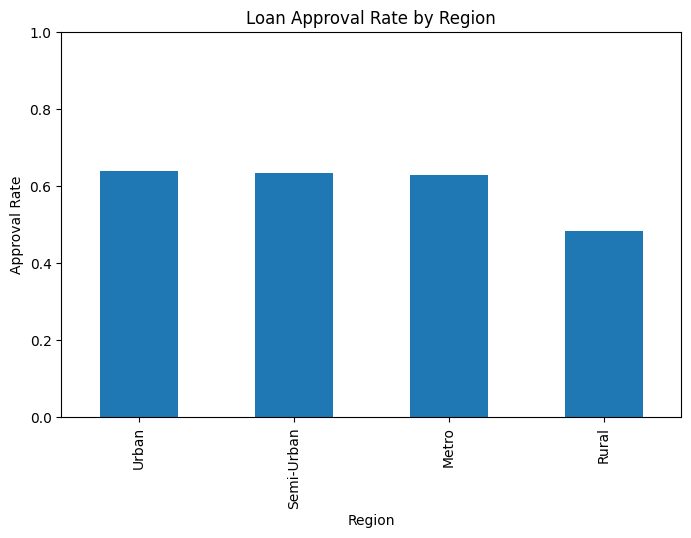

In [ ]:
# STEP 7: Visualize approval rates by region
# This graph helps students see whether approval rates differ across locations.
#
# In finance, region may be a legitimate risk factor in some contexts,
# but it can also act as a proxy for socioeconomic background.
#
# Therefore, managers must ask:
# Is the difference due to real repayment risk, or due to historical bias?

approval_by_region = approval_rate_by_group("region")

approval_by_region.plot(kind="bar", figsize=(8, 5))
plt.title("Loan Approval Rate by Region")
plt.xlabel("Region")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.show()

In [ ]:
# STEP 8: Define features and target variable
# X contains input features used by the model.
# y contains the target variable: loan_approved.
#
# We include both numerical and categorical variables.
# Numerical examples: income, credit score, loan amount
# Categorical examples: gender, employment type, region

X = df.drop(columns=["loan_approved"])
y = df["loan_approved"]

numeric_features = [
    "age",
    "annual_income",
    "credit_score",
    "existing_emi",
    "loan_amount",
    "credit_history_years",
    "debt_to_income_ratio"
]

categorical_features = [
    "employment_type",
    "region",
    "gender"
]

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'annual_income', 'credit_score', 'existing_emi', 'loan_amount', 'credit_history_years', 'debt_to_income_ratio']
Categorical features: ['employment_type', 'region', 'gender']


In [ ]:
# STEP 9: Split dataset into training and testing data
# Training data is used to teach the model.
# Testing data is used to evaluate model performance on unseen examples.
#
# stratify=y ensures that approval/rejection ratio remains similar in train and test sets.
# This is good practice in classification problems.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1125
Testing rows: 375


In [ ]:
# STEP 10: Build preprocessing and machine learning pipeline
# Machine learning models cannot directly understand text categories like 'Metro' or 'Salaried'.
# Therefore, we use OneHotEncoder to convert categories into numerical columns.
#
# Example:
# region = Metro, Urban, Rural becomes separate binary columns.
#
# RandomForestClassifier is used because:
# - It handles non-linear relationships well.
# - It performs strongly on tabular data.
# - It can capture interactions between variables.
#
# In real banking, models may include logistic regression, gradient boosting, random forest,
# scorecards, or advanced ensemble models depending on governance requirements.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=6,
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [ ]:
# STEP 11: Evaluate model performance
# Accuracy tells overall correctness.
# ROC-AUC tells how well the model separates approved and rejected classes.
# Confusion matrix shows:
# - True approvals correctly predicted
# - True rejections correctly predicted
# - Wrong approvals
# - Wrong rejections
#
# In finance, false approvals may create credit loss.
# False rejections may reject good customers and damage trust.

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.827
ROC-AUC: 0.905

Confusion Matrix:
[[123  23]
 [ 42 187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       146
           1       0.89      0.82      0.85       229

    accuracy                           0.83       375
   macro avg       0.82      0.83      0.82       375
weighted avg       0.83      0.83      0.83       375



In [ ]:
# STEP 12: Prepare transformed feature names
# SHAP and LIME need the final feature names after preprocessing.
# Since categorical variables were one-hot encoded, their names changed.
#
# Example:
# region becomes region_Metro, region_Rural, etc.
#
# This cell extracts the final feature names from the preprocessing pipeline.

trained_preprocessor = pipeline.named_steps["preprocessor"]

encoded_cat_features = (
    trained_preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = numeric_features + list(encoded_cat_features)

print("Total transformed features:", len(all_feature_names))
print(all_feature_names)

Total transformed features: 16
['age', 'annual_income', 'credit_score', 'existing_emi', 'loan_amount', 'credit_history_years', 'debt_to_income_ratio', 'employment_type_Gig Worker', 'employment_type_Salaried', 'employment_type_Self-Employed', 'region_Metro', 'region_Rural', 'region_Semi-Urban', 'region_Urban', 'gender_Female', 'gender_Male']


In [ ]:
# STEP 13: Create transformed training and testing datasets
# The model was trained on transformed numerical data.
# For SHAP, we will use this transformed data.
#
# We convert transformed arrays into DataFrames so that SHAP plots show readable feature names.

X_train_transformed = trained_preprocessor.transform(X_train)
X_test_transformed = trained_preprocessor.transform(X_test)

X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=all_feature_names,
    index=X_train.index
)

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=all_feature_names,
    index=X_test.index
)

X_test_transformed_df.head()

,age,annual_income,credit_score,existing_emi,loan_amount,credit_history_years,debt_to_income_ratio,employment_type_Gig Worker,employment_type_Salaried,employment_type_Self-Employed,region_Metro,region_Rural,region_Semi-Urban,region_Urban,gender_Female,gender_Male
615,55.0,981257.0,536.0,14252.0,746079.0,3.0,0.17,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
273,42.0,1002123.0,782.0,12565.0,357564.0,19.0,0.15,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1080,39.0,399883.0,798.0,31961.0,999580.0,8.0,0.96,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
884,29.0,774811.0,671.0,27912.0,676836.0,5.0,0.43,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
687,54.0,639499.0,640.0,10467.0,100000.0,0.0,0.20,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# LAB 3: SHAP EXPLAINABILITY
# STEP 14: Create SHAP explainer
# SHAP explains how each feature pushes the model prediction up or down.
#
# For classification:
# - Positive SHAP value pushes prediction toward approval.
# - Negative SHAP value pushes prediction toward rejection.
#
# TreeExplainer is suitable for tree-based models such as Random Forest.

rf_model = pipeline.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)

# To keep Colab fast, we explain only a sample of test rows.
X_shap_sample = X_test_transformed_df.sample(200, random_state=42)

shap_values = explainer.shap_values(X_shap_sample)

print("SHAP values calculated successfully.")
print("Sample shape:", X_shap_sample.shape)

SHAP values calculated successfully.
Sample shape: (200, 16)


/tmp/ipykernel_3715/1661766665.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


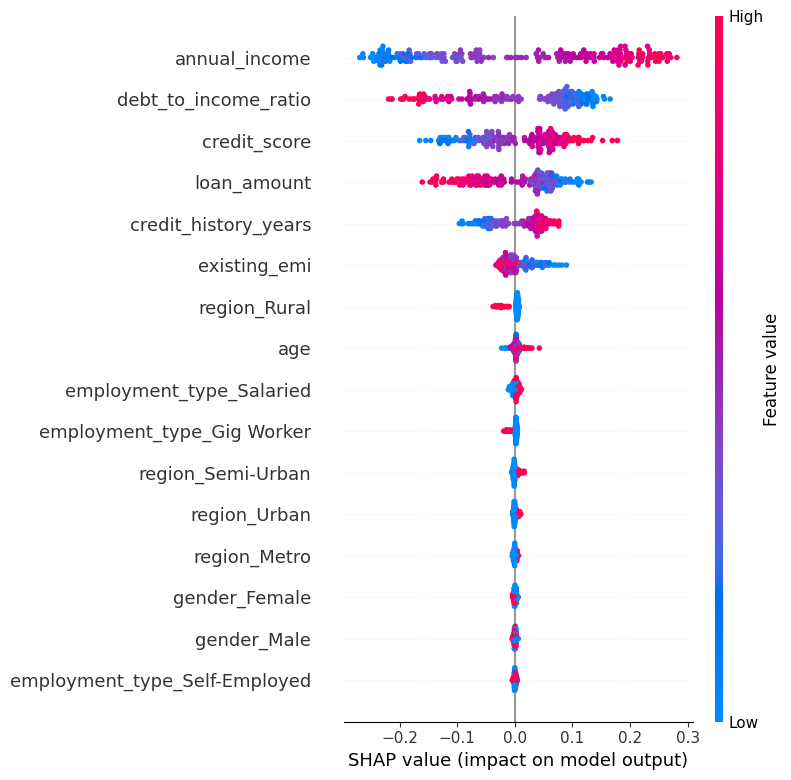

In [ ]:
# STEP 15: SHAP summary plot for global explainability
# This plot shows which features were most important overall.
#
# How to read:
# - Features at the top are more influential.
# - Each dot represents one applicant.
# - Position shows whether the feature increased or decreased prediction.
#
# For loan approval:
# - credit_score may push approval upward.
# - high debt_to_income_ratio may push approval downward.
#
# Note:
# Depending on SHAP version, binary classification output can be a list or array.
# This cell handles both cases safely.

if isinstance(shap_values, list):
    shap_values_for_approval = shap_values[1]
else:
    shap_values_for_approval = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

shap.summary_plot(
    shap_values_for_approval,
    X_shap_sample,
    feature_names=all_feature_names
)

/tmp/ipykernel_3715/721864999.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


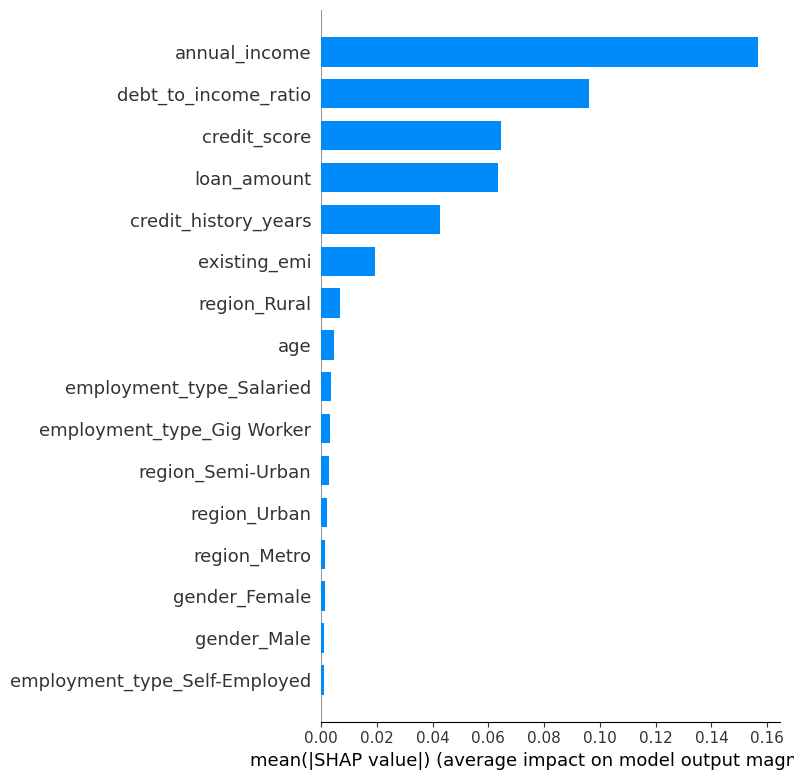

In [ ]:
# STEP 16: SHAP bar plot for feature importance
# The bar plot gives a clean ranking of the most influential features.
#
# This is useful for managers because it answers:
# Which variables are driving loan approval decisions the most?
#
# If sensitive or proxy variables appear very important,
# the model should be reviewed carefully.

shap.summary_plot(
    shap_values_for_approval,
    X_shap_sample,
    feature_names=all_feature_names,
    plot_type="bar"
)

In [ ]:
# STEP 17: Explain one applicant using SHAP
# Global explanation tells us what matters overall.
# Local explanation tells us why ONE specific applicant was approved or rejected.
#
# This is very important in finance because customers ask:
# Why was my loan approved or rejected?

applicant_position = 0

single_applicant = X_shap_sample.iloc[[applicant_position]]
single_original_index = single_applicant.index[0]

print("Original applicant index:", single_original_index)
print("\nOriginal applicant data:")
display(X_test.loc[[single_original_index]])

predicted_probability = pipeline.predict_proba(X_test.loc[[single_original_index]])[0, 1]
predicted_class = pipeline.predict(X_test.loc[[single_original_index]])[0]

print("\nPredicted approval probability:", round(predicted_probability, 3))
print("Predicted class:", "Approved" if predicted_class == 1 else "Rejected")

Original applicant index: 329

Original applicant data:


,age,annual_income,credit_score,existing_emi,loan_amount,employment_type,region,gender,credit_history_years,debt_to_income_ratio
329,45,834385.0,750.0,25679.0,378058.0,Salaried,Semi-Urban,Male,8,0.37



Predicted approval probability: 0.688
Predicted class: Approved


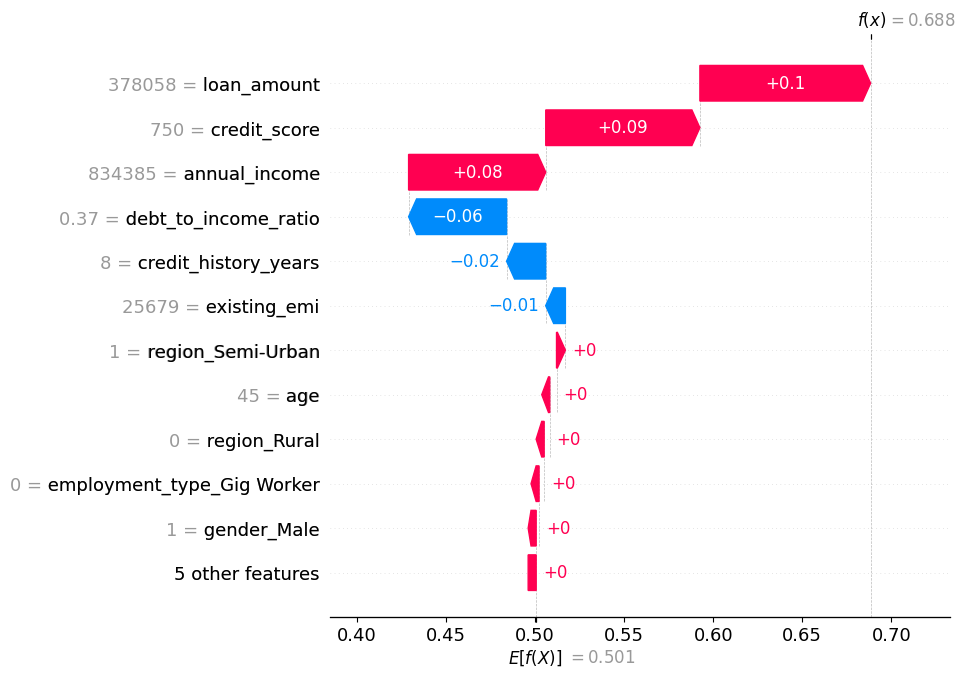

In [ ]:
# STEP 18: SHAP waterfall plot for one applicant
# Waterfall plot explains how each feature contributed to one decision.
#
# base value:
# The model's average expected output.
#
# feature contributions:
# Each feature pushes the prediction higher or lower.
#
# This is useful for:
# - customer explanation
# - risk review
# - internal audit
# - responsible AI governance

# Create explanation object for one applicant.
if isinstance(explainer.expected_value, list):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value[1] if np.ndim(explainer.expected_value) > 0 else explainer.expected_value

single_shap_values = shap_values_for_approval[applicant_position]

shap_explanation = shap.Explanation(
    values=single_shap_values,
    base_values=base_value,
    data=single_applicant.iloc[0].values,
    feature_names=all_feature_names
)

shap.plots.waterfall(shap_explanation, max_display=12)

In [ ]:
# LAB 4: LIME EXPLAINABILITY
# STEP 19: Create a LIME explainer
# LIME explains one prediction by creating many small variations around that applicant.
# Then it builds a simple interpretable model locally.
#
# LIME is model-agnostic.
# This means it can explain many types of models, not only tree models.
#
# In finance, LIME can help explain an individual customer decision.

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_transformed_df),
    feature_names=all_feature_names,
    class_names=["Rejected", "Approved"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer created successfully.")

LIME explainer created successfully.


In [ ]:
# STEP 20: Define prediction function for LIME
# LIME needs a function that accepts transformed data and returns prediction probabilities.
#
# Since our Random Forest model expects already-preprocessed numerical data,
# we pass transformed data directly to the trained Random Forest model.

def lime_predict_proba(transformed_data):
    return rf_model.predict_proba(transformed_data)

print("Prediction function for LIME is ready.")

Prediction function for LIME is ready.


In [ ]:
# STEP 21: Generate LIME explanation for one applicant
# This explanation shows the top factors that influenced approval or rejection.
#
# Positive contribution:
# Pushes decision toward approval.
#
# Negative contribution:
# Pushes decision toward rejection.
#
# The output is simple and useful for teaching managerial explainability.

lime_exp = lime_explainer.explain_instance(
    data_row=single_applicant.iloc[0].values,
    predict_fn=lime_predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

In [ ]:
# STEP 22: Show LIME explanation as a readable table
# This table is useful if students want to copy insights into a report.
#
# Each row shows:
# - Feature condition
# - Direction and strength of influence

lime_table = pd.DataFrame(
    lime_exp.as_list(),
    columns=["Feature Condition", "Contribution"]
)

lime_table

,Feature Condition,Contribution
0,debt_to_income_ratio > 0.36,-0.211736
1,680428.00 < annual_income <= 860641.00,-0.102477
2,loan_amount <= 429091.00,0.100601
3,698.00 < credit_score <= 752.00,0.049175
4,region_Semi-Urban > 0.00,0.027165
5,region_Rural <= 0.00,0.023741
6,existing_emi > 24136.00,-0.009993
7,0.00 < employment_type_Salaried <= 1.00,0.009457
8,5.00 < credit_history_years <= 10.00,-0.007380
9,region_Metro <= 0.00,0.004146


In [ ]:
# STEP 23: Compare SHAP and LIME explanations
# SHAP and LIME both explain model decisions, but they work differently.
#
# SHAP:
# - Based on Shapley values from game theory.
# - Strong for global and local explanations.
# - Often more mathematically consistent.
#
# LIME:
# - Creates a simple local model around one prediction.
# - Easy to understand for non-technical users.
# - Useful for explaining one customer case.
#
# MBA Finance interpretation:
# SHAP is useful for model governance and audit.
# LIME is useful for explaining individual customer decisions.

comparison = pd.DataFrame({
    "Aspect": [
        "Main Purpose",
        "Best Use in Finance",
        "Explanation Level",
        "Managerial Use",
        "Limitation"
    ],
    "SHAP": [
        "Measures contribution of each feature using Shapley values",
        "Model audit, feature importance, fairness investigation",
        "Global and local",
        "Understand which variables drive decisions across portfolio",
        "Can be computationally heavier"
    ],
    "LIME": [
        "Builds simple local explanation around one prediction",
        "Customer-level explanation and case review",
        "Mainly local",
        "Explain why one applicant was approved or rejected",
        "Explanation may vary with sampling"
    ]
})

comparison

,Aspect,SHAP,LIME
0,Main Purpose,Measures contribution of each feature using Sh...,Builds simple local explanation around one pre...
1,Best Use in Finance,"Model audit, feature importance, fairness inve...",Customer-level explanation and case review
2,Explanation Level,Global and local,Mainly local
3,Managerial Use,Understand which variables drive decisions acr...,Explain why one applicant was approved or reje...
4,Limitation,Can be computationally heavier,Explanation may vary with sampling


In [ ]:
# STEP 24: Create a simple business explanation for the selected applicant
# This cell converts model output into business language.
#
# In a real bank, such explanations must be carefully validated before sharing with customers.
# But this shows how AI explainability can support customer communication.

selected_applicant = X_test.loc[[single_original_index]].copy()

prob = pipeline.predict_proba(selected_applicant)[0, 1]
decision = "Approved" if prob >= 0.5 else "Rejected"

print("Business Explanation")
print("--------------------")
print("Decision:", decision)
print("Approval Probability:", round(prob, 3))

print("\nApplicant profile:")
for col in selected_applicant.columns:
    print(f"- {col}: {selected_applicant.iloc[0][col]}")

print("\nPossible explanation based on major financial factors:")
print("- Higher credit score generally supports approval.")
print("- Higher annual income generally supports approval.")
print("- Higher debt-to-income ratio generally reduces approval chances.")
print("- Larger requested loan amount may increase credit risk.")
print("- Short credit history may reduce model confidence.")
print("- Region and employment type should be reviewed carefully because they may create proxy-bias concerns.")

Business Explanation
--------------------
Decision: Approved
Approval Probability: 0.688

Applicant profile:
- age: 45
- annual_income: 834385.0
- credit_score: 750.0
- existing_emi: 25679.0
- loan_amount: 378058.0
- employment_type: Salaried
- region: Semi-Urban
- gender: Male
- credit_history_years: 8
- debt_to_income_ratio: 0.37

Possible explanation based on major financial factors:
- Higher credit score generally supports approval.
- Higher annual income generally supports approval.
- Higher debt-to-income ratio generally reduces approval chances.
- Larger requested loan amount may increase credit risk.
- Short credit history may reduce model confidence.
- Region and employment type should be reviewed carefully because they may create proxy-bias concerns.


In [ ]:
# STEP 25: Fairness reflection activity
# This is a classroom discussion activity.
#
# Students should not only run the model.
# They should interpret model behavior from an ethical finance perspective.

questions = [
    "1. Which features are most important according to SHAP?",
    "2. Are any sensitive or proxy variables influencing decisions?",
    "3. Is region strongly affecting loan approval?",
    "4. Is employment type affecting self-employed or gig workers unfairly?",
    "5. Can the institution explain rejection decisions clearly?",
    "6. What should be reviewed before deploying this model in a real bank?",
    "7. Should customer-facing reason codes be generated automatically?",
    "8. Should borderline cases be reviewed by human credit officers?",
    "9. What business risk arises if good borrowers are rejected at scale?",
    "10. How can responsible AI become a competitive advantage in finance?"
]

for q in questions:
    print(q)

1. Which features are most important according to SHAP?
2. Are any sensitive or proxy variables influencing decisions?
3. Is region strongly affecting loan approval?
4. Is employment type affecting self-employed or gig workers unfairly?
5. Can the institution explain rejection decisions clearly?
6. What should be reviewed before deploying this model in a real bank?
7. Should customer-facing reason codes be generated automatically?
8. Should borderline cases be reviewed by human credit officers?
9. What business risk arises if good borrowers are rejected at scale?
10. How can responsible AI become a competitive advantage in finance?


In [ ]:
# STEP 26: Student task - Try another applicant
# Change applicant_position below to any number between 0 and 199.
# Then rerun this cell to study another applicant.
#
# This helps students see that different customers receive different explanations.

applicant_position = 5

new_single_applicant = X_shap_sample.iloc[[applicant_position]]
new_original_index = new_single_applicant.index[0]

print("Original applicant index:", new_original_index)
display(X_test.loc[[new_original_index]])

new_probability = pipeline.predict_proba(X_test.loc[[new_original_index]])[0, 1]
new_prediction = pipeline.predict(X_test.loc[[new_original_index]])[0]

print("Predicted approval probability:", round(new_probability, 3))
print("Predicted class:", "Approved" if new_prediction == 1 else "Rejected")

new_lime_exp = lime_explainer.explain_instance(
    data_row=new_single_applicant.iloc[0].values,
    predict_fn=lime_predict_proba,
    num_features=10
)

new_lime_exp.show_in_notebook(show_table=True)

Original applicant index: 737


,age,annual_income,credit_score,existing_emi,loan_amount,employment_type,region,gender,credit_history_years,debt_to_income_ratio
737,42,708663.0,713.0,16614.0,1016338.0,Self-Employed,Metro,Male,12,0.28


Predicted approval probability: 0.281
Predicted class: Rejected


In [ ]:
# STEP 27: Final learning summary
# Key takeaways for MBA Finance students:
#
# 1. AI can improve speed and efficiency in financial decisions.
# 2. But financial AI must be explainable because decisions affect real customers.
# 3. SHAP helps identify which features influence the model globally and locally.
# 4. LIME helps explain one individual decision in simple language.
# 5. Accuracy alone is not enough in finance.
# 6. Fairness, transparency, privacy, and accountability are essential.
# 7. Proxy variables such as region, device type, or employment type must be reviewed carefully.
# 8. Human review is important for borderline or high-impact decisions.
# 9. Responsible AI reduces regulatory, reputational, and customer trust risks.
# 10. Modern finance leaders must ask not only 'Is the model accurate?' but also 'Is the model fair and explainable?'

print("Lab completed successfully.")
print("You have built a synthetic loan approval model and explained it using SHAP and LIME.")

Lab completed successfully.
You have built a synthetic loan approval model and explained it using SHAP and LIME.
